# Sales Time Series, Categorical & Textual Data Exploration — Unit III

## Day 1: Time Series Fundamentals — Loading, Plotting, and Decomposition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/sales_timeseries_reviews.csv'

In [ ]:
import os
print(os.getcwd())

In [ ]:
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

In [ ]:
plt.savefig("outputs/day1_raw_series.png", dpi=120)

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(ts, color="steelblue", linewidth=1)
plt.title("Daily Sales Over Time (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.savefig("outputs/day1_raw_series.png", dpi=120)
plt.show()

In [ ]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(ts, color="steelblue", linewidth=1)
plt.title("Daily Sales Over Time (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.tight_layout()
plt.savefig("outputs/day1_raw_series.png", dpi=120)
plt.show()

## Day 2: Lag & Autocorrelation Analysis

In [2]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

NameError: name 'ts' is not defined

In [3]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

NameError: name 'ts' is not defined

In [4]:
ts_df = df.set_index("Date")
ts = ts_df["Daily_Sales"]
ts.head()

NameError: name 'df' is not defined

In [5]:
df = pd.read_csv("data/sales_timeseries_reviews.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Category,Daily_Sales,Customer_Review
0,2024-01-01,Electronics,567.62,"Absolutely love this product, works great and ..."
1,2024-01-02,Beauty,531.15,"Average quality, nothing special but works fine."
2,2024-01-03,Electronics,565.57,"Disappointed with the quality, broke after a w..."
3,2024-01-04,Electronics,550.97,"The product is okay, does what it says."
4,2024-01-05,Home & Kitchen,453.92,"Terrible experience, product stopped working q..."


In [6]:
ts_df = df.set_index("Date")
ts = ts_df["Daily_Sales"]
ts.head()

Date
2024-01-01    567.62
2024-01-02    531.15
2024-01-03    565.57
2024-01-04    550.97
2024-01-05    453.92
Name: Daily_Sales, dtype: float64

In [7]:
lag_df = pd.DataFrame({"Daily_Sales": ts})
lag_df["Lag_1"] = lag_df["Daily_Sales"].shift(1)
lag_df["Lag_7"] = lag_df["Daily_Sales"].shift(7)
lag_df["Lag_30"] = lag_df["Daily_Sales"].shift(30)
lag_df.head(10)

,Daily_Sales,Lag_1,Lag_7,Lag_30
Date,,,,
2024-01-01,567.62,NaN,NaN,NaN
2024-01-02,531.15,567.62,NaN,NaN
2024-01-03,565.57,531.15,NaN,NaN
2024-01-04,550.97,565.57,NaN,NaN
2024-01-05,453.92,550.97,NaN,NaN
2024-01-06,455.97,453.92,NaN,NaN
2024-01-07,470.31,455.97,NaN,NaN
2024-01-08,449.93,470.31,567.62,NaN
2024-01-09,610.59,449.93,531.15,NaN


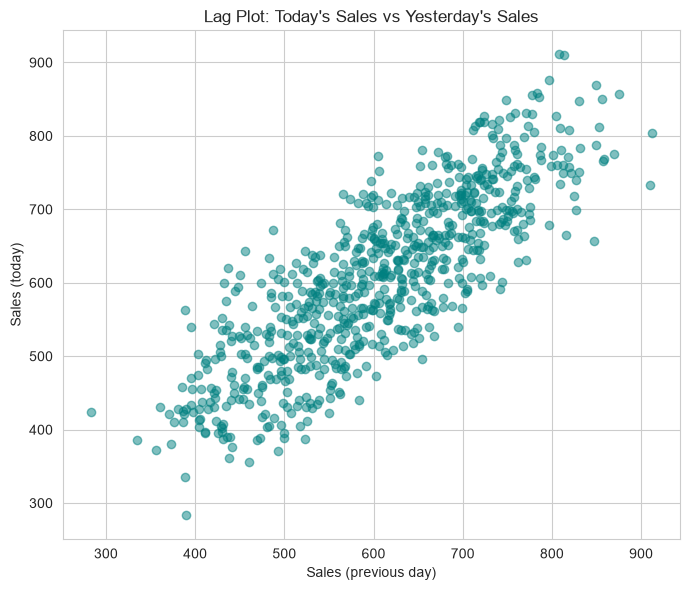

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(lag_df["Lag_1"], lag_df["Daily_Sales"], alpha=0.5, color="teal")
plt.xlabel("Sales (previous day)")
plt.ylabel("Sales (today)")
plt.title("Lag Plot: Today's Sales vs Yesterday's Sales")
plt.tight_layout()
plt.savefig("outputs/day2_lag_plot.png", dpi=120)
plt.show()

In [9]:
for lag in [1, 7, 30]:
    corr = lag_df["Daily_Sales"].corr(lag_df[f"Lag_{lag}"])
    print(f"Correlation with lag {lag} day(s): {corr:.3f}")

Correlation with lag 1 day(s): 0.829
Correlation with lag 7 day(s): 0.874
Correlation with lag 30 day(s): 0.609


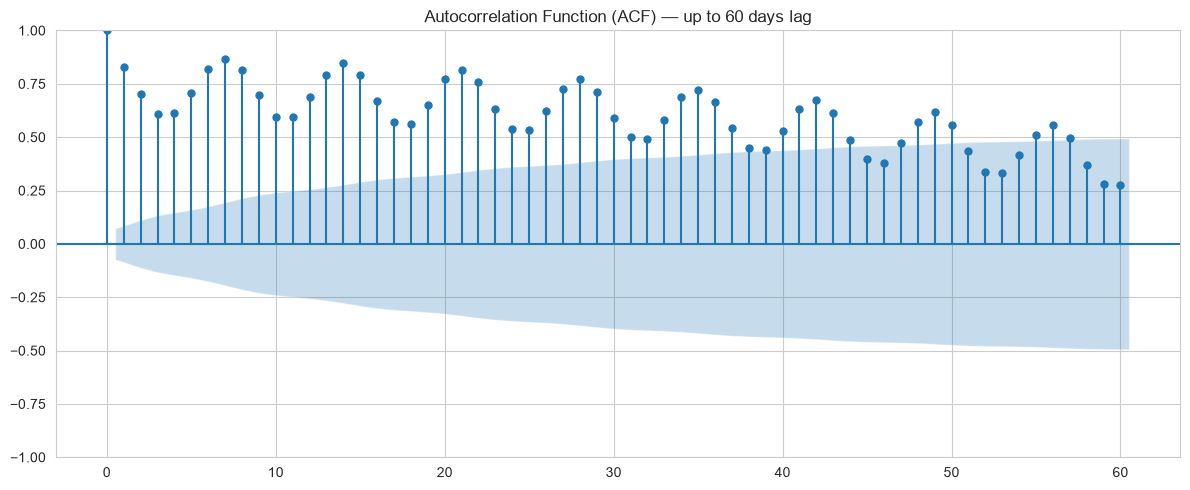

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts, lags=60, ax=ax)
plt.title("Autocorrelation Function (ACF) — up to 60 days lag")
plt.tight_layout()
plt.savefig("outputs/day2_acf_plot.png", dpi=120)
plt.show()

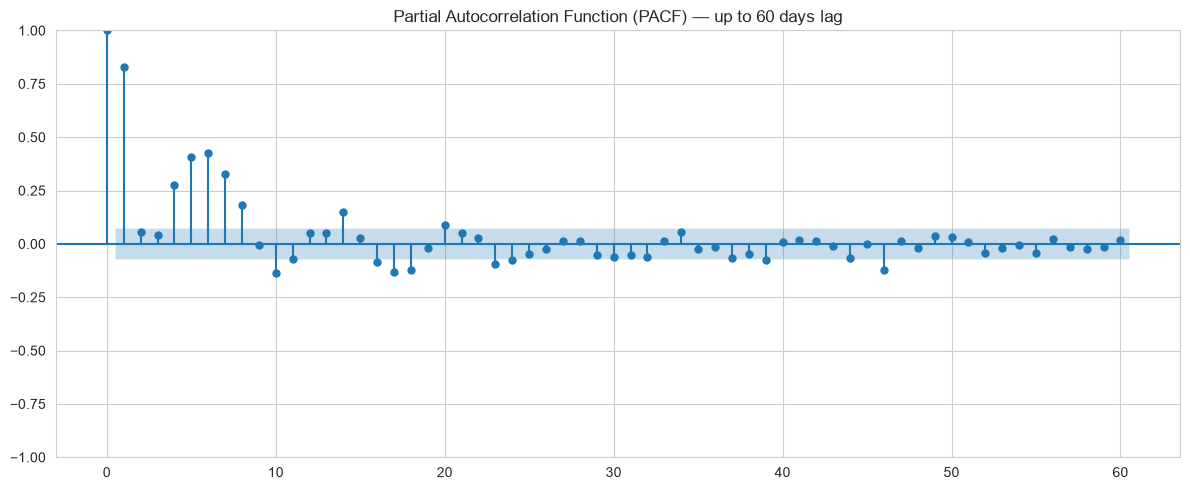

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(ts, lags=60, ax=ax, method="ywm")
plt.title("Partial Autocorrelation Function (PACF) — up to 60 days lag")
plt.tight_layout()
plt.savefig("outputs/day2_pacf_plot.png", dpi=120)
plt.show()

**Observation:** The lag plot shows a moderate positive relationship between
consecutive days. The ACF plot reveals a repeating pattern with notable
spikes around multiples of 7 days, confirming the weekly seasonality we
spotted visually in Day 1's zoomed-in June chart. The PACF helps distinguish
genuine direct dependencies from the "carried-over" correlation that ACF
alone can't separate out — useful when later choosing lag features or an
ARIMA-style model.